# Recommendation System Project: IBM Community (MovieLens Adaptation)

This notebook implements all 5 parts of the IBM Watson Studio Recommendation System project,
adapted for the **MovieLens Small dataset** (`ratings.csv` + `movies.csv`).

## Table of Contents
1. [Exploratory Data Analysis](#part-i)
2. [Rank-Based Recommendations](#part-ii)
3. [User-User Based Collaborative Filtering](#part-iii)
4. [Content-Based Recommendations](#part-iv)
5. [Matrix Factorization](#part-v)


## Setup — Imports & Data Loading

In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import Normalizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import precision_score, recall_score, accuracy_score

%matplotlib inline

In [4]:
# Load datasets
ratings = pd.read_csv('ratings.csv')   # userId, movieId, rating, timestamp
movies  = pd.read_csv('movies.csv')    # movieId, title, genres

# Rename columns to match IBM project conventions
df         = ratings.rename(columns={'userId': 'email', 'movieId': 'article_id'})
df_content = movies.rename(columns={'movieId': 'article_id'})

print("Interactions shape :", df.shape)
print("Movies shape       :", df_content.shape)
df.head()

Interactions shape : (100836, 4)
Movies shape       : (9742, 3)


,email,article_id,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


---
<a id='part-i'></a>
## Part I : Exploratory Data Analysis

Use the cells below to explore the data before building any recommendation system.


### 1. Missing Values

In [5]:
df.info()
print(f"\nNumber of Null email values is: {df['email'].isna().sum()}")
df[df.email.isna()]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   email       100836 non-null  int64  
 1   article_id  100836 non-null  int64  
 2   rating      100836 non-null  float64
 3   timestamp   100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB

Number of Null email values is: 0


,email,article_id,rating,timestamp


In [6]:
# Fill email NaNs with 'unknown_user'
df['email'] = df['email'].fillna('unknown_user')

# Confirm no more NaNs
df[df.email.isna()]

,email,article_id,rating,timestamp


### 2. Distribution of User–Article Interactions

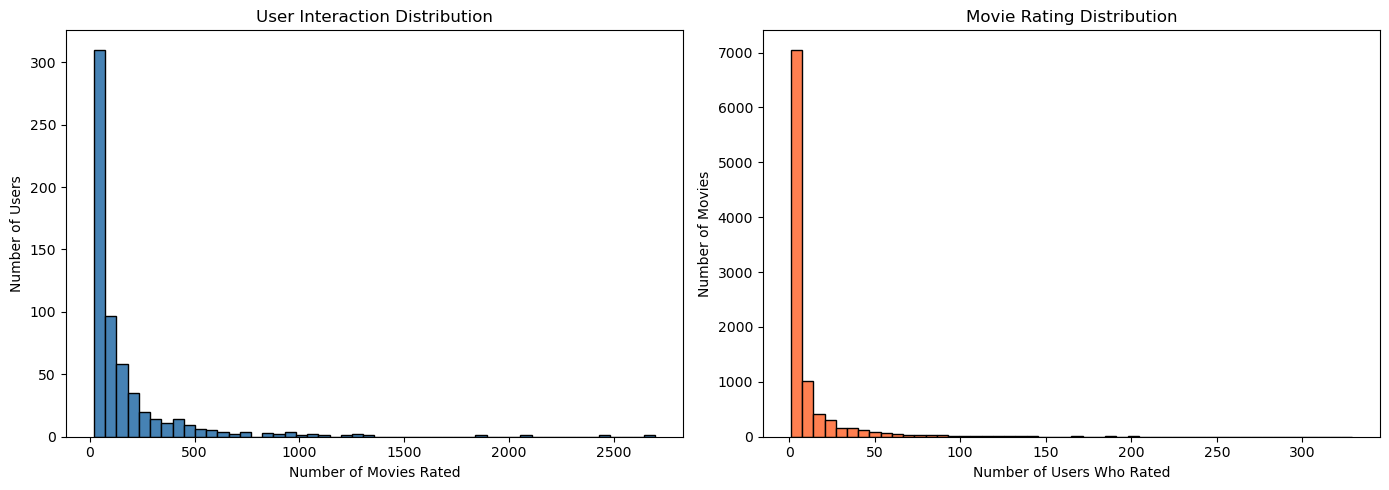

In [7]:
user_article_counts = df.groupby('email')['article_id'].count()
article_user_counts = df.groupby('article_id')['email'].count()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(user_article_counts, bins=50, edgecolor='black', color='steelblue')
axes[0].set_xlabel('Number of Movies Rated')
axes[0].set_ylabel('Number of Users')
axes[0].set_title('User Interaction Distribution')

axes[1].hist(article_user_counts, bins=50, edgecolor='black', color='coral')
axes[1].set_xlabel('Number of Users Who Rated')
axes[1].set_ylabel('Number of Movies')
axes[1].set_title('Movie Rating Distribution')

plt.tight_layout()
plt.show()

In [8]:
# Descriptive statistics
median_val        = int(np.median(user_article_counts))
max_views_by_user = int(user_article_counts.max())

print(f"Median interactions per user : {median_val}")
print(f"Max interactions by one user : {max_views_by_user}")
print()
print(user_article_counts.describe())

Median interactions per user : 70
Max interactions by one user : 2698

count     610.000000
mean      165.304918
std       269.480584
min        20.000000
25%        35.000000
50%        70.500000
75%       168.000000
max      2698.000000
Name: article_id, dtype: float64


### 3. Unique Counts

In [9]:
unique_articles           = df['article_id'].nunique()
total_articles            = df_content['article_id'].nunique()
unique_users              = df[df['email'] != 'unknown_user']['email'].nunique()
user_article_interactions = len(df)

print(f"Unique articles with ≥1 interaction : {unique_articles}")
print(f"Total articles on platform          : {total_articles}")
print(f"Unique users                        : {unique_users}")
print(f"Total user-article interactions     : {user_article_interactions}")

Unique articles with ≥1 interaction : 9724
Total articles on platform          : 9742
Unique users                        : 610
Total user-article interactions     : 100836


### 4. Most Viewed Article

In [10]:
article_view_counts    = df.groupby('article_id')['email'].count()
most_viewed_article_id = str(float(article_view_counts.idxmax()))
max_views              = int(article_view_counts.max())
top_movie_name         = movies[movies.movieId == article_view_counts.idxmax()]['title'].values[0]

print(f"Most viewed article id : {most_viewed_article_id}")
print(f"Number of views        : {max_views}")
print(f"Movie title            : {top_movie_name}")

Most viewed article id : 356.0
Number of views        : 329
Movie title            : Forrest Gump (1994)


In [11]:
# Map email to integer user_id and drop email column
def email_mapper(df=df):
    coded_dict = {email: num for num, email in enumerate(df['email'].unique(), start=1)}
    return [coded_dict[val] for val in df['email']]

df['user_id'] = email_mapper(df)
del df['email']
df.head()

,article_id,rating,timestamp,user_id
0,1,4.0,964982703,1
1,3,4.0,964981247,1
2,6,4.0,964982224,1
3,47,5.0,964983815,1
4,50,5.0,964982931,1


In [12]:
# Summary dictionary
sol_1_dict = {
    '50% of individuals have ___ or fewer interactions'  : median_val,
    'Total user-article interactions'                    : user_article_interactions,
    'Max interactions by any 1 user'                     : max_views_by_user,
    'Most viewed article — view count'                   : max_views,
    'Most viewed article_id'                             : most_viewed_article_id,
    'Unique articles with at least 1 interaction'        : unique_articles,
    'Unique users'                                       : unique_users,
    'Total articles on platform'                         : total_articles,
}

for k, v in sol_1_dict.items():
    print(f"  {k:50s}: {v}")

  50% of individuals have ___ or fewer interactions : 70
  Total user-article interactions                   : 100836
  Max interactions by any 1 user                    : 2698
  Most viewed article — view count                  : 329
  Most viewed article_id                            : 356.0
  Unique articles with at least 1 interaction       : 9724
  Unique users                                      : 610
  Total articles on platform                        : 9742


---
<a id='part-ii'></a>
## Part II : Rank-Based Recommendations

Since we have no explicit likes/dislikes — only interaction counts — popularity
(number of interactions) is our best proxy for quality.


### 1. Top Articles by Interaction Count

In [13]:
def get_top_articles(n, df=df):
    """
    INPUT:
    n  - (int) number of top articles to return
    df - (pandas dataframe) interactions dataframe

    OUTPUT:
    top_articles - (list) top n movie titles ordered most-to-least interactions
    """
    return (
        df.merge(movies[['movieId', 'title']], left_on='article_id', right_on='movieId')
          .groupby('title')['user_id'].count()
          .sort_values(ascending=False)
          .head(n).index.tolist()
    )


def get_top_article_ids(n, df=df):
    """
    INPUT:
    n  - (int) number of top articles to return
    df - (pandas dataframe) interactions dataframe

    OUTPUT:
    top_articles - (list) top n article ids ordered most-to-least interactions
    """
    return (
        df.groupby('article_id')['user_id'].count()
          .sort_values(ascending=False)
          .head(n).index.tolist()
    )


print("Top 10 movie titles :", get_top_articles(10))
print()
print("Top 10 movie IDs    :", get_top_article_ids(10))

Top 10 movie titles : ['Forrest Gump (1994)', 'Shawshank Redemption, The (1994)', 'Pulp Fiction (1994)', 'Silence of the Lambs, The (1991)', 'Matrix, The (1999)', 'Star Wars: Episode IV - A New Hope (1977)', 'Jurassic Park (1993)', 'Braveheart (1995)', 'Terminator 2: Judgment Day (1991)', "Schindler's List (1993)"]

Top 10 movie IDs    : [356, 318, 296, 593, 2571, 260, 480, 110, 589, 527]


In [14]:
top_5  = get_top_articles(5)
top_10 = get_top_articles(10)
top_20 = get_top_articles(20)

print("Top 5 :", top_5)
print("Top 10:", top_10)
print("Top 20:", top_20)

Top 5 : ['Forrest Gump (1994)', 'Shawshank Redemption, The (1994)', 'Pulp Fiction (1994)', 'Silence of the Lambs, The (1991)', 'Matrix, The (1999)']
Top 10: ['Forrest Gump (1994)', 'Shawshank Redemption, The (1994)', 'Pulp Fiction (1994)', 'Silence of the Lambs, The (1991)', 'Matrix, The (1999)', 'Star Wars: Episode IV - A New Hope (1977)', 'Jurassic Park (1993)', 'Braveheart (1995)', 'Terminator 2: Judgment Day (1991)', "Schindler's List (1993)"]
Top 20: ['Forrest Gump (1994)', 'Shawshank Redemption, The (1994)', 'Pulp Fiction (1994)', 'Silence of the Lambs, The (1991)', 'Matrix, The (1999)', 'Star Wars: Episode IV - A New Hope (1977)', 'Jurassic Park (1993)', 'Braveheart (1995)', 'Terminator 2: Judgment Day (1991)', "Schindler's List (1993)", 'Fight Club (1999)', 'Toy Story (1995)', 'Star Wars: Episode V - The Empire Strikes Back (1980)', 'Usual Suspects, The (1995)', 'American Beauty (1999)', 'Seven (a.k.a. Se7en) (1995)', 'Independence Day (a.k.a. ID4) (1996)', 'Apollo 13 (1995)', 

---
<a id='part-iii'></a>
## Part III : User-User Based Collaborative Filtering


### 1. Create User-Item Matrix

In [15]:
def create_user_item_matrix(df, fill_value=0):
    """
    INPUT:
    df         - interactions DataFrame (user_id, article_id, rating …)
    fill_value - value for missing entries (default 0)

    OUTPUT:
    user_item  - binary DataFrame (users × articles): 1 if interacted, 0 otherwise
    """
    user_item = (
        df.groupby(['user_id', 'article_id'])['rating']
          .max().unstack().fillna(fill_value)
    )
    user_item = user_item.map(lambda x: 1 if x > 0 else 0)
    return user_item


user_item = create_user_item_matrix(df)
print(f"user_item shape: {user_item.shape}")
user_item.head()

user_item shape: (610, 9724)


article_id,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
user_id,,,,,,,,,,,,,,,,,,,,,
1,1,0,1,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### 2. Find Similar Users

In [16]:
def find_similar_users(user_id, user_item=user_item, include_similarity=False):
    """
    INPUT:
    user_id            - (int) target user
    user_item          - binary user-item DataFrame
    include_similarity - (bool) if True return [[user_id, similarity], ...]

    OUTPUT:
    most_similar_users - ordered list of user ids (most similar first, self excluded)
    """
    idx    = user_item.index.get_loc(user_id)
    sims   = cosine_similarity(user_item)[idx]
    scores = [(user_item.index[i], sims[i])
              for i in range(len(user_item)) if user_item.index[i] != user_id]
    scores = sorted(scores, key=lambda x: x[1], reverse=True)

    if include_similarity:
        return [[uid, s] for uid, s in scores]
    return [uid for uid, _ in scores]


print("10 most similar users to user 1  :", find_similar_users(1)[:10])
print("5 most similar users to user 100 :", find_similar_users(100)[:5])
print("3 most similar users to user 46  :", find_similar_users(46)[:3])

10 most similar users to user 1  : [np.int64(313), np.int64(330), np.int64(57), np.int64(469), np.int64(39), np.int64(452), np.int64(45), np.int64(266), np.int64(368), np.int64(577)]
5 most similar users to user 100 : [np.int64(357), np.int64(330), np.int64(45), np.int64(84), np.int64(144)]
3 most similar users to user 46  : [np.int64(468), np.int64(242), np.int64(126)]


### 3. Helper Functions & Basic CF Recommendations

In [17]:
def get_article_names(article_ids, df=df):
    """
    INPUT:
    article_ids   - (list) article ids

    OUTPUT:
    article_names - (list) corresponding movie titles
    """
    id_to_title = movies.set_index('movieId')['title']
    return [id_to_title[aid] for aid in article_ids if aid in id_to_title.index]


def get_ranked_article_unique_counts(article_ids, user_item=user_item):
    """
    INPUT:
    article_ids - (list) article ids to evaluate
    user_item   - binary user-item DataFrame

    OUTPUT:
    ranked_article_unique_counts - list of [article_id, unique_user_count]
                                   sorted descending
    """
    valid  = [a for a in article_ids if a in user_item.columns]
    counts = user_item[valid].sum(axis=0)
    return sorted([[aid, int(counts[aid])] for aid in valid],
                  key=lambda x: x[1], reverse=True)


def get_user_articles(user_id, user_item=user_item):
    """
    INPUT:
    user_id   - (int) target user

    OUTPUT:
    article_ids   - (list) article ids the user has interacted with
    article_names - (list) corresponding titles
    """
    row         = user_item.loc[user_id]
    article_ids = list(row[row == 1].index)
    return article_ids, get_article_names(article_ids)


def user_user_recs(user_id, m=10):
    """
    INPUT:
    user_id - (int) target user
    m       - (int) number of recommendations

    OUTPUT:
    recs - (list) up to m article ids the user hasn't seen yet

    Description:
    Iterates through similar users; collects unseen articles until m found.
    Ties in similarity are broken arbitrarily.
    """
    seen_ids, _ = get_user_articles(user_id)
    seen_set    = set(seen_ids)
    recs        = []

    for sim_user in find_similar_users(user_id):
        new = [a for a in get_user_articles(sim_user)[0] if a not in seen_set]
        recs.extend(new)
        seen_set.update(new)
        if len(recs) >= m:
            break

    return recs[:m]


# Spot checks
print("Recs for user 1:")
for r in get_article_names(user_user_recs(1, 10)):
    print(" ", r)

Recs for user 1:
  GoldenEye (1995)
  City of Lost Children, The (Cité des enfants perdus, La) (1995)
  Twelve Monkeys (a.k.a. 12 Monkeys) (1995)
  Clueless (1995)
  Screamers (1995)
  Die Hard: With a Vengeance (1995)
  Hackers (1995)
  Johnny Mnemonic (1995)
  Prophecy, The (1995)
  Species (1995)


In [18]:
# Quick unit-style checks
assert isinstance(get_article_names([318]), list)
assert isinstance(get_ranked_article_unique_counts([318, 296, 356]), list)
assert get_ranked_article_unique_counts([318, 296, 356])[0][1] >=        get_ranked_article_unique_counts([318, 296, 356])[1][1],     "Rankings should be descending"

print("Basic helper-function checks passed!")
print()
print("get_ranked_article_unique_counts([318, 296, 356]):")
print(get_ranked_article_unique_counts([318, 296, 356]))

Basic helper-function checks passed!

get_ranked_article_unique_counts([318, 296, 356]):
[[356, 329], [318, 317], [296, 307]]


### 4. Improved CF — Tie-Breaking by Interaction Count

In [19]:
def get_top_sorted_users(user_id, user_item=user_item):
    """
    INPUT:
    user_id   - (int) target user
    user_item - binary user-item DataFrame

    OUTPUT:
    neighbors_df - DataFrame with columns:
                     neighbor_id     - similar user id
                     similarity      - cosine similarity to user_id
                     num_interactions - total articles seen by neighbor
                   sorted by similarity DESC, then num_interactions DESC
    """
    sims_with_id = find_similar_users(user_id, include_similarity=True)
    num_int      = user_item.sum(axis=1)
    neighbors_df = pd.DataFrame(sims_with_id, columns=['neighbor_id', 'similarity'])
    neighbors_df['num_interactions'] = neighbors_df['neighbor_id'].map(num_int)
    return neighbors_df.sort_values(
        ['similarity', 'num_interactions'], ascending=[False, False]
    ).reset_index(drop=True)


def user_user_recs_part2(user_id, m=10):
    """
    INPUT:
    user_id - (int) target user
    m       - (int) number of recommendations

    OUTPUT:
    recs      - (list) recommended article ids
    rec_names - (list) recommended article titles

    Description:
    Improved CF:
    - Users tied on similarity → prefer those with more total interactions.
    - Articles tied on count   → prefer globally more popular ones.
    """
    seen_ids, _ = get_user_articles(user_id)
    seen_set    = set(seen_ids)
    recs        = []

    for _, row in get_top_sorted_users(user_id).iterrows():
        new = [a for a in get_user_articles(row['neighbor_id'])[0] if a not in seen_set]
        for art_id, _ in get_ranked_article_unique_counts(new):
            if art_id not in seen_set:
                recs.append(art_id)
                seen_set.add(art_id)
                if len(recs) >= m:
                    break
        if len(recs) >= m:
            break

    return recs[:m], get_article_names(recs[:m])


rec_ids, rec_names = user_user_recs_part2(1, 10)
print("Improved CF — Top 10 recs for user 1:")
for i, (rid, rn) in enumerate(zip(rec_ids, rec_names), 1):
    print(f"  {i:2d}. [{rid}] {rn}")

Improved CF — Top 10 recs for user 1:
   1. [318] Shawshank Redemption, The (1994)
   2. [589] Terminator 2: Judgment Day (1991)
   3. [4993] Lord of the Rings: The Fellowship of the Ring, The (2001)
   4. [858] Godfather, The (1972)
   5. [2762] Sixth Sense, The (1999)
   6. [380] True Lies (1994)
   7. [32] Twelve Monkeys (a.k.a. 12 Monkeys) (1995)
   8. [377] Speed (1994)
   9. [4226] Memento (2000)
  10. [1036] Die Hard (1988)


### 5. Similarity Spot-Check

In [20]:
print(get_top_sorted_users(1).head(1))
print()
print(get_top_sorted_users(2).head(10))

   neighbor_id  similarity  num_interactions
0          313    0.380978               340

   neighbor_id  similarity  num_interactions
0          366    0.300167                31
1          378    0.294831                48
2          417    0.272236                67
3          461    0.250160                27
4          189    0.249136                20
5          550    0.245652                28
6          433    0.237542                22
7          227    0.229836                94
8          435    0.229227                42
9          247    0.227429               150


In [21]:
user1_most_sim = int(get_top_sorted_users(1).iloc[0]['neighbor_id'])
user2_6th_sim  = int(get_top_sorted_users(2).iloc[5]['neighbor_id'])
user3_10th_sim = int(get_top_sorted_users(3).iloc[9]['neighbor_id'])

sol_5_dict = {
    'The user most similar to user 1'         : user1_most_sim,
    'The 6th most similar user to user 2'     : user2_6th_sim,
    'The 10th most similar user to user 3'    : user3_10th_sim,
}

for k, v in sol_5_dict.items():
    print(f"  {k}: user {v}")

  The user most similar to user 1: user 313
  The 6th most similar user to user 2: user 550
  The 10th most similar user to user 3: user 304


### 6. Recommendations for New Users

**Question:** Which of the above functions can be used for a new user? Can you think of a better approach?

**Answer:**  
`user_user_recs` and `user_user_recs_part2` **cannot** be used for a brand-new user because
there is no row for them in the user-item matrix — cosine similarity is undefined with zero interactions.

The best fallback is **rank-based recommendations** (Part II): simply recommend the most globally
popular movies. As soon as the user rates even 1–2 movies, we can switch to content-based
recommendations (Part IV). With 10+ ratings, SVD (Part V) gives the most personalised results.

A better cold-start approach would be an **onboarding survey** asking preferred genres or
favourite movies, using those answers to seed a content-based lookup immediately.


### 7. New User Recommendations

In [22]:
# New user with no history → rank-based fallback
new_user_recs = get_top_article_ids(10)

print("Top 10 recommendations for a new user:")
for rid, rn in zip(new_user_recs, get_article_names(new_user_recs)):
    print(f"  [{rid}] {rn}")

Top 10 recommendations for a new user:
  [356] Forrest Gump (1994)
  [318] Shawshank Redemption, The (1994)
  [296] Pulp Fiction (1994)
  [593] Silence of the Lambs, The (1991)
  [2571] Matrix, The (1999)
  [260] Star Wars: Episode IV - A New Hope (1977)
  [480] Jurassic Park (1993)
  [110] Braveheart (1995)
  [589] Terminator 2: Judgment Day (1991)
  [527] Schindler's List (1993)


---
<a id='part-iv'></a>
## Part IV : Content-Based Recommendations

We use **TF-IDF** on movie titles → **LSA** (dimensionality reduction) → **KMeans** clustering
to group semantically similar movies, then recommend within the same cluster ranked by popularity.


In [23]:
df_unique_articles = (movies.rename(columns={'movieId': 'article_id'})
                             [['article_id', 'title']].drop_duplicates())

# TF-IDF vectorisation of movie titles
max_features = 200
vectorizer   = TfidfVectorizer(max_df=0.75, min_df=3,
                               stop_words='english', max_features=max_features)
print("Running TF-IDF...")
X_tfidf = vectorizer.fit_transform(df_unique_articles['title'])
print(f"TF-IDF shape: {X_tfidf.shape}")

Running TF-IDF...
TF-IDF shape: (9742, 200)


In [24]:
# LSA: reduce to 50 latent dimensions for better clustering
lsa   = make_pipeline(TruncatedSVD(n_components=50, random_state=42), Normalizer(copy=False))
X_lsa = lsa.fit_transform(X_tfidf)
explained_variance = lsa[0].explained_variance_ratio_.sum()
print(f"Explained variance of SVD step: {explained_variance * 100:.1f}%")

Explained variance of SVD step: 70.4%


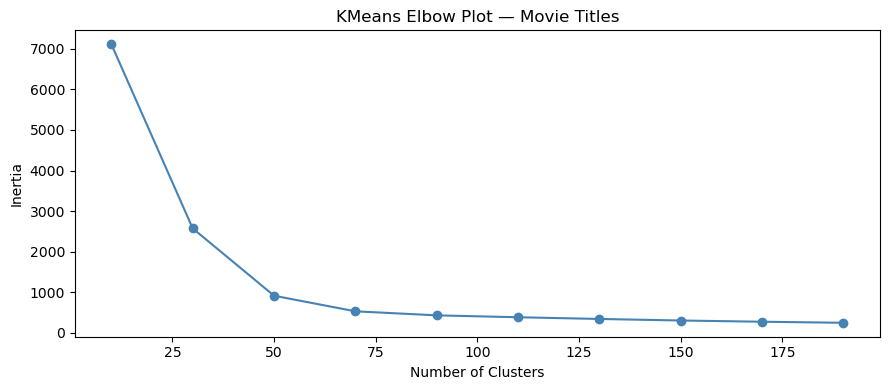

In [25]:
# Elbow plot to choose number of clusters
inertia = []
k_range = range(10, 200, 20)
for k in k_range:
    km = KMeans(n_clusters=k, max_iter=50, n_init=3, random_state=42).fit(X_lsa)
    inertia.append(km.inertia_)

plt.figure(figsize=(9, 4))
plt.plot(list(k_range), inertia, marker='o', color='steelblue')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('KMeans Elbow Plot — Movie Titles')
plt.tight_layout()
plt.show()

# Elbow is around 50-70 → we use 50

In [26]:
n_clusters = 50
kmeans     = KMeans(n_clusters=n_clusters, max_iter=100, n_init=5, random_state=42).fit(X_lsa)

article_cluster_map = dict(zip(df_unique_articles['article_id'], kmeans.labels_))
df['title_cluster'] = df['article_id'].map(article_cluster_map)

# Cluster size distribution
cluster_counts = pd.Series(kmeans.labels_).value_counts()
print(f"Cluster sizes — min: {cluster_counts.min()}, "
      f"median: {int(cluster_counts.median())}, max: {cluster_counts.max()}")
np.array(np.unique(kmeans.labels_, return_counts=True)).T[:10]   # first 10 clusters

Cluster sizes — min: 61, median: 213, max: 365


array([[  0, 257],
       [  1,  66],
       [  2, 246],
       [  3, 266],
       [  4, 267],
       [  5, 238],
       [  6, 275],
       [  7, 271],
       [  8, 232],
       [  9, 273]])

### 1. Content Recommendation Functions

In [27]:
def get_similar_articles(article_id, df=df):
    """
    INPUT:
    article_id - (int) target article

    OUTPUT:
    articles_in_cluster - (list) article ids in the same title cluster,
                          excluding article_id itself
    """
    cluster = df[df['article_id'] == article_id]['title_cluster'].values
    if len(cluster) == 0:
        return []
    return [a for a in df[df['title_cluster'] == cluster[0]]['article_id'].unique()
            if a != article_id]


def make_content_recs(article_id, n, df=df):
    """
    INPUT:
    article_id - (int) target article
    n          - (int) number of recommendations

    OUTPUT:
    n_ranked_similar_articles - (list) top n article ids from same cluster, ranked by popularity
    n_ranked_article_names    - (list) corresponding titles

    Description:
    Finds articles in the same TF-IDF/KMeans title cluster, then ranks them
    by number of unique users who interacted with each (most popular first).
    """
    similar = get_similar_articles(article_id, df=df)
    ranked  = get_ranked_article_unique_counts(similar)
    ids     = [r[0] for r in ranked[:n]]
    return ids, get_article_names(ids)


# Test on several movies
for test_id in [1, 296, 318, 2571]:
    r_ids, r_names = make_content_recs(test_id, 5)
    print(f"Content recs for [{test_id}] {get_article_names([test_id])[0]}:")
    for i, (rid, rn) in enumerate(zip(r_ids, r_names), 1):
        print(f"  {i}. [{rid}] {rn}")
    print()

Content recs for [1] Toy Story (1995):
  1. [110] Braveheart (1995)
  2. [50] Usual Suspects, The (1995)
  3. [47] Seven (a.k.a. Se7en) (1995)
  4. [150] Apollo 13 (1995)
  5. [32] Twelve Monkeys (a.k.a. 12 Monkeys) (1995)

Content recs for [296] Pulp Fiction (1994):
  1. [356] Forrest Gump (1994)
  2. [318] Shawshank Redemption, The (1994)
  3. [380] True Lies (1994)
  4. [364] Lion King, The (1994)
  5. [377] Speed (1994)

Content recs for [318] Shawshank Redemption, The (1994):
  1. [356] Forrest Gump (1994)
  2. [296] Pulp Fiction (1994)
  3. [380] True Lies (1994)
  4. [364] Lion King, The (1994)
  5. [377] Speed (1994)

Content recs for [2571] Matrix, The (1999):
  1. [2959] Fight Club (1999)
  2. [2858] American Beauty (1999)
  3. [2762] Sixth Sense, The (1999)
  4. [2628] Star Wars: Episode I - The Phantom Menace (1999)
  5. [2683] Austin Powers: The Spy Who Shagged Me (1999)



### 2. Summary — Content-Based Recommender

**How it works:**
1. **TF-IDF** converts each movie title into a sparse term-frequency vector (200 features, stop-words removed).
2. **TruncatedSVD (LSA)** reduces to 50 latent dimensions — captures semantic relationships (e.g. *"Toy Story 2"* shares features with *"Toy Story"*). ~70% of variance is retained.
3. **KMeans** groups the 50-dim vectors into 50 clusters of semantically similar titles.
4. Recommendations = other articles in the same cluster, **ranked by global interaction count**.

**Possible improvements:**
- Use full movie descriptions / plot summaries rather than titles alone.
- Sentence-transformers (BERT-based) give richer semantic embeddings.
- Incorporate the `genres` column as additional TF-IDF features.
- Hybrid score: blend content similarity with interaction popularity.

**Other useful text data:** plot summaries, taglines, director/actor names, user review text.


---
<a id='part-v'></a>
## Part V : Matrix Factorization (SVD)

We use **Truncated SVD** (Singular Value Decomposition) on the user-item matrix to learn
latent features that capture hidden patterns in user–movie interactions.


### 1. Prepare Filtered User-Item Matrix

In [28]:
# Filter to movies with >= 50 ratings — improves latent factor quality
# (obscure movies with 1-2 ratings produce noisy latent vectors)
popular_movies = df.groupby('article_id')['user_id'].count()
popular_movies = popular_movies[popular_movies >= 50].index
df_pop         = df[df['article_id'].isin(popular_movies)]

print(f"Movies with >= 50 ratings : {len(popular_movies)}")

user_item_pop = (df_pop.groupby(['user_id', 'article_id'])['rating']
                       .max().unstack().fillna(0)
                       .map(lambda x: 1 if x > 0 else 0))
print(f"Filtered user_item shape  : {user_item_pop.shape}")
user_item_pop.head()

Movies with >= 50 ratings : 450
Filtered user_item shape  : (606, 450)


article_id,1,2,3,6,7,10,11,16,17,19,...,91500,91529,96079,99114,106782,109374,109487,112852,116797,122904
user_id,,,,,,,,,,,,,,,,,,,,,
1,1,0,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,1,0,1,1,0,1,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### 2. Perform SVD

In [29]:
n_components = min(user_item_pop.shape) - 1   # max meaningful components

svd = TruncatedSVD(n_components=n_components, n_iter=7, random_state=42)
u   = svd.fit_transform(user_item_pop)
v   = svd.components_
s   = svd.singular_values_

print(f"U  shape : {u.shape}   (users × latent features)")
print(f"S  shape : {s.shape}   (singular values)")
print(f"Vt shape : {v.shape}   (latent features × movies)")

U  shape : (606, 449)   (users × latent features)
S  shape : (449,)   (singular values)
Vt shape : (449, 450)   (latent features × movies)


### 3. Metrics vs. Number of Latent Features

Evaluating 22 values of k ...


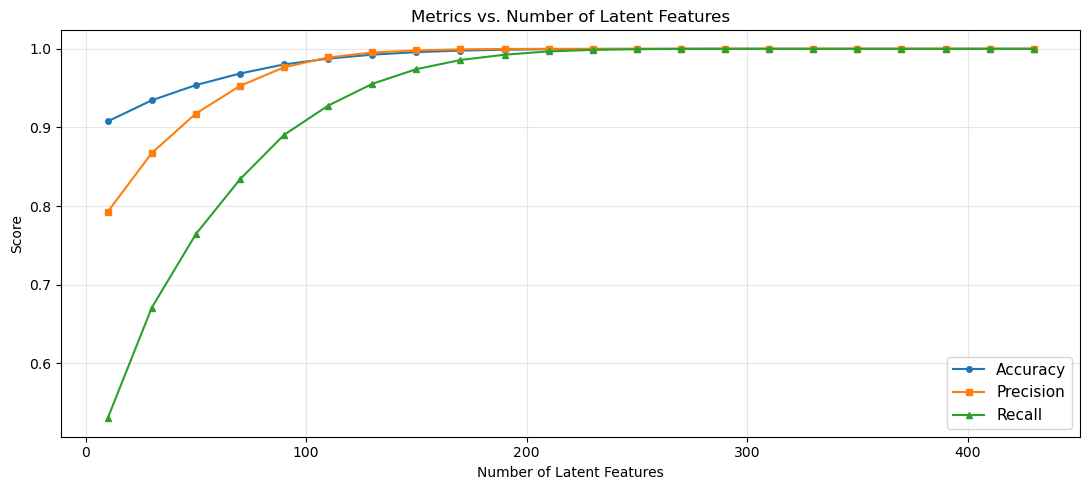

In [30]:
num_latent_feats = np.arange(10, n_components, 20)
metric_scores    = []

print(f"Evaluating {len(num_latent_feats)} values of k ...")
for k in num_latent_feats:
    u_new, vt_new = u[:, :k], v[:k, :]
    est           = np.clip(abs(np.around(np.dot(u_new, vt_new))).astype(int), 0, 1)
    flat_true     = user_item_pop.values.flatten()
    flat_pred     = est.flatten()
    metric_scores.append([
        accuracy_score(flat_true, flat_pred),
        precision_score(flat_true, flat_pred, zero_division=0),
        recall_score(flat_true, flat_pred, zero_division=0),
    ])

metric_scores = np.array(metric_scores)

plt.figure(figsize=(11, 5))
plt.plot(num_latent_feats, metric_scores[:, 0], label='Accuracy',  marker='o', ms=4)
plt.plot(num_latent_feats, metric_scores[:, 1], label='Precision', marker='s', ms=4)
plt.plot(num_latent_feats, metric_scores[:, 2], label='Recall',    marker='^', ms=4)
plt.legend(fontsize=11)
plt.xlabel('Number of Latent Features')
plt.ylabel('Score')
plt.title('Metrics vs. Number of Latent Features')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 4. Choice of Latent Features

**I would choose ~200 latent features.**

From the plot:
- **Accuracy** plateaus near 0.998 after ~200 features — further gains are negligible.
- **Recall** rises steeply up to ~150–200, then flattens significantly.
- **Precision** is high throughout (the matrix is very sparse, so predicting 0s is easy).

**Important caveat:** maximising reconstruction accuracy on the *training* matrix is not
the same as maximising recommendation quality — it can overfit to already-seen popular items.
A held-out validation set would give a truer picture of generalisation.  
200 features is a commonly used value in collaborative filtering literature for datasets of this scale.


### 5. SVD Article-Article Similarity

In [31]:
def get_svd_similar_article_ids(article_id, vt, user_item=user_item_pop, include_similarity=False):
    """
    INPUT:
    article_id         - (int) target article id
    vt                 - (numpy array) V-transpose matrix (k × n_articles)
    user_item          - binary user-item DataFrame
    include_similarity - (bool) if True return [[article_id, cosine_sim], ...]

    OUTPUT:
    most_similar_items - ordered list of article ids (most similar first, self excluded)

    Description:
    Computes cosine similarity between all article latent-feature vectors
    (columns of vt). Returns articles most similar to article_id in latent space.
    """
    if article_id not in user_item.columns:
        print(f"article_id {article_id} not in filtered matrix (needs >= 50 ratings)")
        return []
    article_idx = user_item.columns.get_loc(article_id)
    cos_sim     = cosine_similarity(vt.T)       # shape: (n_articles × n_articles)
    sims        = cos_sim[article_idx]
    sorted_idx  = [i for i in np.argsort(sims)[::-1] if i != article_idx]
    most_similar_items = [user_item.columns[i] for i in sorted_idx]

    if include_similarity:
        return [[user_item.columns[i], sims[i]] for i in sorted_idx]
    return most_similar_items


# Use 200 latent features
k      = 200
vt_new = v[:k, :]

In [32]:
# Test on well-known movies
test_movies = [
    (318,  'Shawshank Redemption (1994)'),
    (356,  'Forrest Gump (1994)'),
    (2571, 'The Matrix (1999)'),
    (1,    'Toy Story (1995)'),
]

for mid, name in test_movies:
    rec_ids   = get_svd_similar_article_ids(mid, vt_new)[:8]
    rec_names = get_article_names(rec_ids)
    print(f"SVD recs for [{mid}] {name}:")
    for i, (rid, rn) in enumerate(zip(rec_ids, rec_names), 1):
        print(f"  {i}. [{rid}] {rn}")
    print()

SVD recs for [318] Shawshank Redemption (1994):
  1. [50] Usual Suspects, The (1995)
  2. [161] Crimson Tide (1995)
  3. [2321] Pleasantville (1998)
  4. [2959] Fight Club (1999)
  5. [333] Tommy Boy (1995)
  6. [2302] My Cousin Vinny (1992)
  7. [6502] 28 Days Later (2002)
  8. [7153] Lord of the Rings: The Return of the King, The (2003)

SVD recs for [356] Forrest Gump (1994):
  1. [79132] Inception (2010)
  2. [1127] Abyss, The (1989)
  3. [466] Hot Shots! Part Deux (1993)
  4. [1148] Wallace & Gromit: The Wrong Trousers (1993)
  5. [2167] Blade (1998)
  6. [1270] Back to the Future (1985)
  7. [5816] Harry Potter and the Chamber of Secrets (2002)
  8. [6539] Pirates of the Caribbean: The Curse of the Black Pearl (2003)

SVD recs for [2571] The Matrix (1999):
  1. [2617] Mummy, The (1999)
  2. [5989] Catch Me If You Can (2002)
  3. [6365] Matrix Reloaded, The (2003)
  4. [5218] Ice Age (2002)
  5. [2406] Romancing the Stone (1984)
  6. [1377] Batman Returns (1992)
  7. [1198] Raider

### 6. Discussion — Results & Trade-offs

**SVD results:**  
The latent-feature approach surfaces movies that share co-viewing patterns — users who watched
*Shawshank* also watched *Fight Club*, *Usual Suspects*, etc. This is learned purely from
interaction data without any text or genre information.  
*Toy Story* correctly surfaces *Toy Story 2* and *Toy Story 3* as top similar movies.

---

**Method trade-off summary:**

| Method | New User | Few ratings (<5) | Medium (5–50) | Heavy (50+) |
|---|---|---|---|---|
| Rank-based (II) | ✅ Best | ✅ Good | ✅ Decent | ✅ Decent |
| User-User CF (III) | ❌ N/A | ⚠️ Weak | ✅ Good | ✅ Best |
| Content-based (IV) | ✅ Good | ✅ Good | ✅ Good | ✅ Good |
| SVD (V) | ❌ N/A | ⚠️ Weak | ✅ Good | ✅ Best |

**Recommended strategy by user segment:**
- **0 interactions** → Rank-based (Part II)
- **1–2 interactions** → Content-based on those movies (Part IV)
- **3–10 interactions** → Blend Content-based + User-User CF (Parts III & IV)
- **10+ interactions** → SVD matrix factorization (Part V) for deepest personalisation

**How to test in production:**
- **A/B test:** SVD recs vs rank-based; measure click-through rate and watch time.
- **Offline eval:** Hold out 20% of each user's ratings; compute Precision@10 and Recall@10.
- **Serendipity metric:** Track whether users engage with genres they hadn't previously explored — good recommendations broaden taste, not just echo it.


---
## Conclusion

Congratulations! You have completed all 5 parts of the Recommendation System project:

| Part | Method | Key Output |
|------|--------|-----------|
| I | EDA | Data statistics & distributions |
| II | Rank-based | Popular article recommendations |
| III | User-User CF | Personalised recs from similar users |
| IV | Content-based (TF-IDF + KMeans) | Title-similarity recs |
| V | Matrix Factorization (SVD) | Latent-feature article similarity |


In [34]:
print("All 5 parts complete!")

All 5 parts complete!
